# 12j — Physical Vulnerability (Damage) Curves

Covers `chap12_vulnerability1-3`: the Huizinga (JRC) flood depth-damage
curves, split first by infrastructure type (fixed to the Europe region)
and then by world region (fixed to Residential buildings), and a
parametric cubic wind-speed vulnerability function in the Emanuel
tropical-cyclone-damage style, for 3 illustrative parameter sets.

This is the last notebook of Chapter 12 — with `12j` complete, all 50
`chap12_*.m` exercise scripts across `12a`-`12j` are accounted for, 0
of them blocked by missing or unreadable data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from csaps import csaps

DATA_DIR = "../../data"

color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_violet  = "#ff33ff"
color_orange  = "#ffa500"
color_teal    = "#388e8e"
color_black   = "#000000"

colors = [color_blue, color_red, color_green, color_violet, color_orange, color_teal]

plt.rcParams["figure.dpi"] = 100


## 1. Flood depth-damage curves by infrastructure type, Europe (`chap12_vulnerability1`)

The Huizinga et al. flood depth-damage function (damage as % of asset
value vs. flood depth) for 6 infrastructure types, fixed to the Europe
region, fit with a smoothing spline (`csaps`, smoothing parameter 0.9,
weight 10 at the two endpoints) through 9 discrete depth points (0-6m),
and sorted by damage severity at the 2m-depth row (MATLAB's `damage(5,:)`,
row 5 of the 9 depth values `[0, 0.5, 1, 1.5, 2, 3, 4, 5, 6]`).

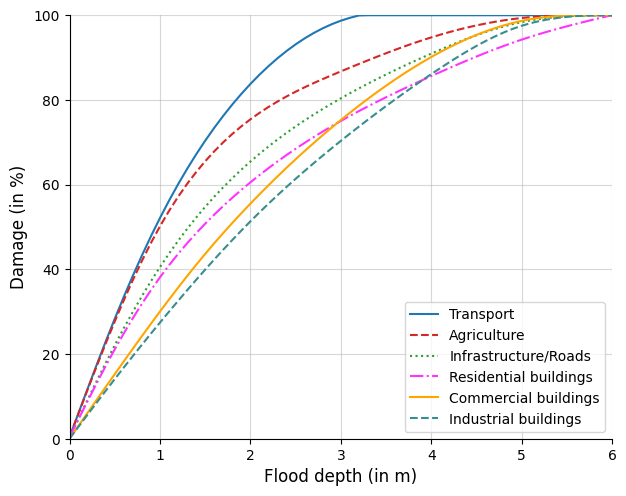

In [2]:
huiz = pd.read_excel(f"{DATA_DIR}/chap12_ext_huizinga_flood.xlsx", sheet_name="Damage function")

infrastructure = huiz["Infrastructure"].values.reshape(9, 6, order="F")
depth = huiz["Depth"].values.reshape(9, 6, order="F")
damage = huiz["Europe"].values.reshape(9, 6, order="F")

# Sort the 6 infrastructure-type columns by damage severity at the 2m-depth
# row (0-indexed row 4 == MATLAB's 1-indexed damage(5,:))
order = np.argsort(-damage[4, :])
infrastructure = infrastructure[:, order]
depth = depth[:, order]
damage = damage[:, order]

typ = ["-", "--", ":", "-.", "-", "--"]
x = np.arange(0, 6.01, 0.1)
w = np.ones(9)
w[0] = 10
w[-1] = 10

fig, ax = plt.subplots(figsize=(7, 5.5))
for i in range(6):
    y = csaps(depth[:, i], damage[:, i], x, weights=w, smooth=0.9)
    ax.plot(x, 100 * np.minimum(y, 1), typ[i], color=colors[i], linewidth=1.5, label=infrastructure[0, i])

ax.set_xlabel("Flood depth (in m)", fontsize=12)
ax.set_ylabel("Damage (in %)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 6)
ax.set_ylim(0, 100)
plt.show()


## 2. Flood depth-damage curves by region, Residential buildings (`chap12_vulnerability2`)

Same Huizinga dataset, but now fixed to one infrastructure type
(Residential buildings — the first infrastructure group in the table)
and split by the 6 world regions instead (the `Global` column is
excluded here, matching the source script's `T{:,3:end-1}` column
range).

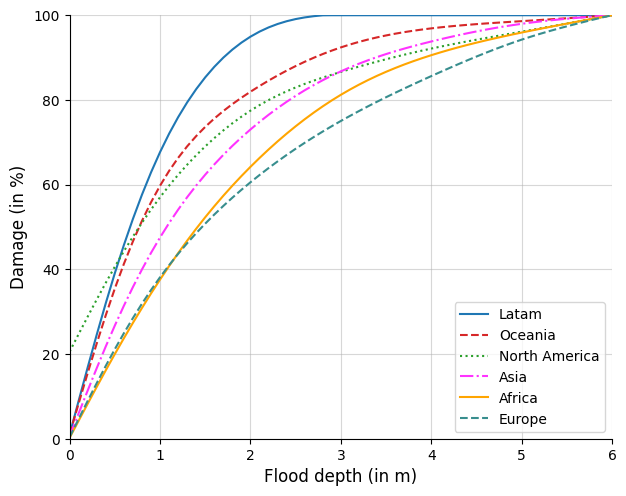

In [3]:
region_cols = ["Europe", "North_America", "Latam", "Asia", "Africa", "Oceania"]
region_labels = ["Europe", "North America", "Latam", "Asia", "Africa", "Oceania"]

first_infra = huiz["Infrastructure"].iloc[0]
sub = huiz[huiz["Infrastructure"] == first_infra]
depth2 = sub["Depth"].values
damage2 = sub[region_cols].values  # (9, 6)

order2 = np.argsort(-damage2[4, :])  # same 2m-depth row (0-indexed 4 == MATLAB row 5)
region_labels_sorted = [region_labels[i] for i in order2]
damage2 = damage2[:, order2]

fig, ax = plt.subplots(figsize=(7, 5.5))
for i in range(6):
    y = csaps(depth2, damage2[:, i], x, weights=w, smooth=0.9)
    ax.plot(x, 100 * np.minimum(y, 1), typ[i], color=colors[i], linewidth=1.5, label=region_labels_sorted[i])

ax.set_xlabel("Flood depth (in m)", fontsize=12)
ax.set_ylabel("Damage (in %)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 6)
ax.set_ylim(0, 100)
plt.show()


## 3. Parametric wind-speed damage curve (`chap12_vulnerability3`)

The classic Emanuel-style tropical-cyclone wind-vulnerability function
$D(w) = \upsilon^3/(1+\upsilon^3)$, $\upsilon = \max(w-w_-,0)/(w_{1/2}-w_-)$,
plotted for 3 `(w_-, w_{1/2})` parameter sets. The source script defines
4 unit-convention variants (m/s, knots, mph, km/h) selectable via an
`if/elseif` block; only the `units==1` (km/h) branch is actually
exercised as written, so only that branch is reproduced here.

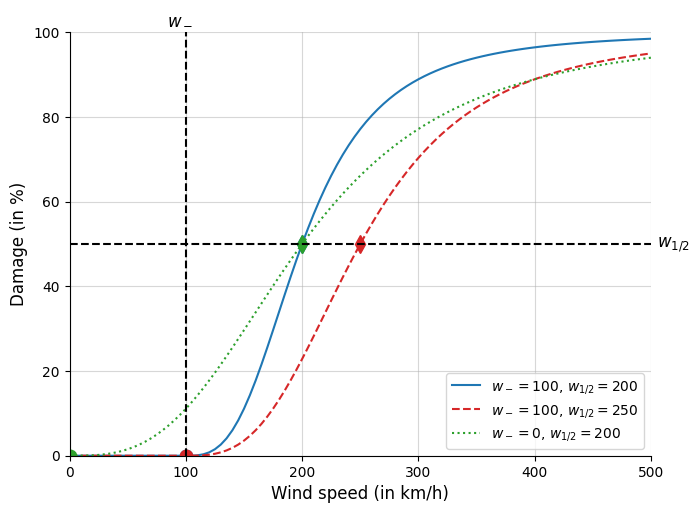

In [4]:
w = np.arange(0, 501, 5.0)
w_minus = np.array([100.0, 100.0, 0.0])
w_half = np.array([200.0, 250.0, 200.0])

upsilon = np.maximum(w[:, None] - w_minus, 0.0) / (w_half - w_minus)
D = upsilon ** 3 / (1 + upsilon ** 3)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i in range(3):
    label = f"$w_-={w_minus[i]:.0f}$, $w_{{1/2}}={w_half[i]:.0f}$"
    ax.plot(w, 100 * D[:, i], typ[i], color=colors[i], linewidth=1.5, label=label)
    ax.plot(w_minus[i], 0, "o", color=colors[i], markersize=9)
    ax.plot(w_half[i], 50, "d", color=colors[i], markersize=9)

ax.plot([100, 100], [0, 100], "--", color=color_black, linewidth=1.5)
ax.plot([0, 500], [50, 50], "--", color=color_black, linewidth=1.5)
ax.text(505, 50, "$w_{1/2}$", fontsize=12, va="center")
ax.text(95, 102, "$w_-$", fontsize=12, ha="center")

ax.set_xlabel("Wind speed (in km/h)", fontsize=12)
ax.set_ylabel("Damage (in %)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 500)
ax.set_ylim(0, 100)
plt.show()
